# **Notebook 2: Exploratory Data Analysis**

# Import Data and Dependencies

In [21]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import ipywidgets
warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set(style="whitegrid")

data_path = kagglehub.dataset_download("andrewsundberg/college-basketball-dataset")
df = pd.read_csv(f"{data_path}/cbb.csv")
df.head()

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,Wisconsin,B10,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,2ND,1.0,2015
2,Michigan,B10,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,2ND,3.0,2018
3,Texas Tech,B12,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,2ND,3.0,2019
4,Gonzaga,WCC,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,2ND,1.0,2017


# Data Filtering

### Postseason Teams

My goal in this project is to examine visually why some low-seeded teams (often called Cinderella teams) advance far in the NCAA tournament. To explore this idea, the first step is to filter the dataset provided by Sundberg from Kaggle to focus only on teams that made the "March Madness" NCAA tournament. This requires finding the teams that have non-null values for the "POSTSEASON" and "SEED" features to create a dataset that is ready for further transformations and subsetting.

In [10]:
df_playoff = df[df["POSTSEASON"].notna() & df["SEED"].notna()]
print(df_playoff.shape)
# the first value in this tuple (748) shows the number of valid tournament entries,
# with each row in the dataframe corresponding to a specific team in a specific year.

(748, 24)


### Deep-Run Teams

The following code subsets the dataset to find teams that made a "deep run" in the playoffs, defined here as reaching the Sweet 16 round, where only 16 of the 68 teams remain.

In [11]:
deep_stages = ['S16', 'E8', 'F4', '2ND', 'Champions']
deep_run_teams = df_playoff[df_playoff["POSTSEASON"].isin(deep_stages)]
deep_run_teams.head()

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,Wisconsin,B10,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,2ND,1.0,2015
2,Michigan,B10,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,2ND,3.0,2018
3,Texas Tech,B12,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,2ND,3.0,2019
4,Gonzaga,WCC,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,2ND,1.0,2017


### "Cinderella Teams"

Cinderella teams are low-seeded teams that advance unexpectedly far in the NCAA March Madness tournament. Each of the four regions contains 16 teams seeded from 1 to 16, so lower seeds typically face stronger opponents early (ex. 1 seed plays a 16 seed). For this analysis, I define Cinderella teams as any team seeded 11 or worse that reaches at least the round of 16 (at least 2 wins in the tournament).

In [12]:
cinderella = deep_run_teams[deep_run_teams["SEED"] >= 11]
cinderella

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
26,Xavier,BE,38,24,115.6,97.9,0.8713,51.9,51.6,18.4,...,33.4,52.0,52.5,34.5,33.4,68.4,1.6,E8,11.0,2017
37,Dayton,A10,37,26,113.0,99.1,0.8188,52.4,48.8,18.1,...,43.0,50.4,48.3,37.7,33.2,65.4,0.6,E8,11.0,2014
47,Loyola Chicago,MVC,37,32,110.5,95.4,0.8444,57.7,47.4,19.1,...,25.2,56.6,47.1,39.8,32.0,66.4,2.0,F4,11.0,2018
2404,Syracuse,ACC,37,23,106.0,92.1,0.8344,46.9,46.2,19.1,...,31.4,46.6,45.1,31.7,31.8,64.0,-0.4,S16,11.0,2018
2427,UCLA,P12,36,22,111.8,96.6,0.8425,49.6,48.5,17.6,...,32.3,47.4,45.4,36.8,35.6,66.8,0.0,S16,11.0,2015
2431,Oregon,P12,38,25,108.1,91.7,0.8687,52.0,46.4,17.8,...,33.9,51.6,48.8,35.1,29.0,65.4,-1.1,S16,12.0,2019
2437,Gonzaga,WCC,35,27,117.4,94.5,0.9238,55.2,44.8,17.1,...,28.1,54.3,44.4,37.8,30.3,68.2,2.1,S16,11.0,2016
2446,Tennessee,SEC,36,23,118.1,93.4,0.9374,49.8,46.5,16.8,...,31.5,50.6,44.5,31.9,34.5,63.1,0.4,S16,11.0,2014
2452,Oregon,P12,37,28,104.8,88.6,0.8728,49.3,46.4,21.4,...,33.3,49.1,44.9,33.3,33.4,69.2,2.9,S16,12.0,2013
2453,La Salle,A10,34,24,112.0,96.2,0.8516,51.9,49.3,17.1,...,28.5,49.3,50.6,37.7,30.2,66.0,0.3,S16,13.0,2013


In [13]:
low_11_16 = df_playoff[df_playoff["SEED"] >= 11].copy() # All playoff teams seeded 11 or higher
low_11_16["MADE_S16"] = low_11_16["POSTSEASON"].isin(["S16","E8","F4","2ND","Champions"])
low_11_16.loc[:, "TEAM_TYPE"] = np.where(
    low_11_16["MADE_S16"], "Cinderella", "Low Seed (No Run)"
)

---

# PRELIMINARY VISUALIZATIONS

## Barplot - Cinderella Teams per year

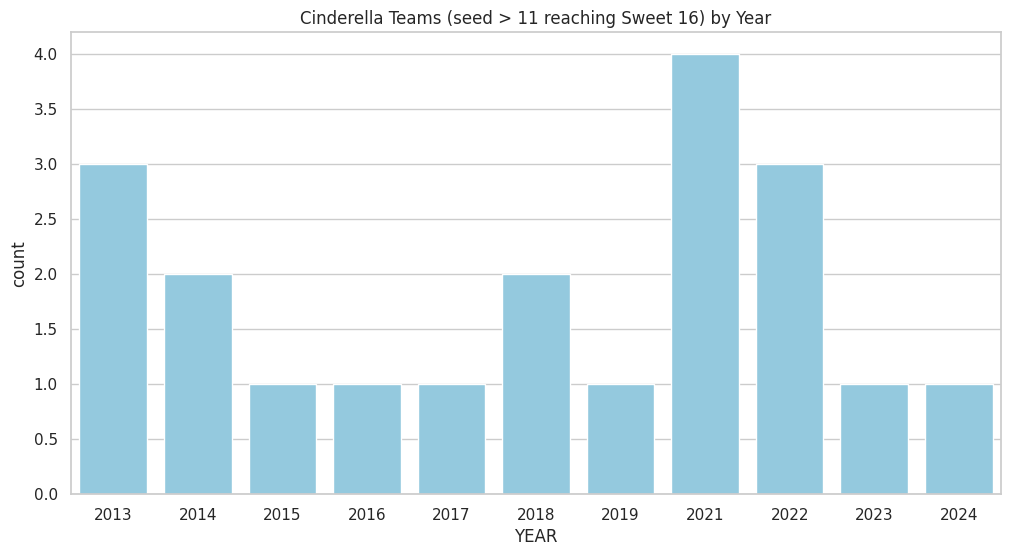

In [14]:
cinderellas_per_year = cinderella.groupby("YEAR").size().reset_index(name="count")
cinderellas_per_year["YEAR"] = pd.to_numeric(cinderellas_per_year["YEAR"])

plt.figure(figsize=(12,6))
sns.barplot(
    data=cinderellas_per_year,
    x="YEAR",
    y="count",
    color="skyblue"
)
plt.title('Cinderella Teams (seed > 11 reaching Sweet 16) by Year')
plt.show()

## Stacked Bar Chart - Low Seed Deep Run Odds

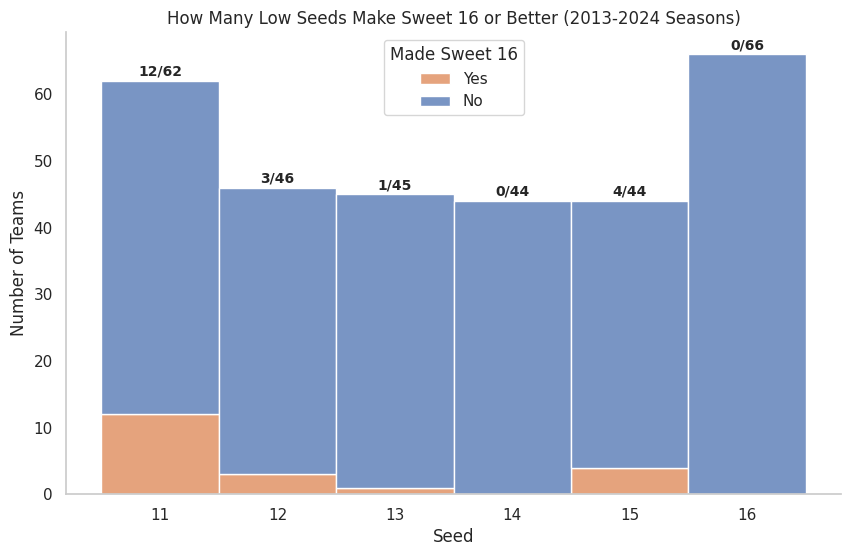

In [15]:
# First I create a df containing only 11 seeds and higher.
df_filtered = df_playoff[df_playoff["SEED"] >= 11]

plt.figure(figsize=(10,6))

ax = sns.histplot(
    data=df_filtered,
    x="SEED",
    hue=df_filtered["POSTSEASON"].isin(["S16","E8","F4","2ND","Champions"]), # coloring by if they are a Cinderella team
    bins=range(9, 18),
    multiple="stack",
    discrete=True
)

plt.title("How Many Low Seeds Make Sweet 16 or Better (2013-2024 Seasons)")
plt.xlabel("Seed")
plt.ylabel("Number of Teams")
plt.legend(title="Made Sweet 16", labels=["Yes", "No"])
plt.grid(False)


# Creating a df for teams in late stages (at least 2 wins)
deep = df_filtered["POSTSEASON"].isin(["S16","E8","F4","2ND","Champions"])

counts = df_filtered.groupby(["SEED", deep]).size().unstack(fill_value=0)
counts.columns = ["No", "Yes"]  # False = No, True = Yes


# Annotating proportions of teams
for seed in counts.index:
    no_count = counts.loc[seed, "No"]
    yes_count = counts.loc[seed, "Yes"]
    total = no_count + yes_count

    plt.text(
        seed,
        total + 0.3,
        f"{yes_count}/{total}",  # shows Cinderella teams / Total 11+ seed teams
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

sns.despine()
plt.show()


## Widgets - Stat Comparison of Cinderella vs. Non-Cinderella (teams seeded 11+ not making Sweet 16)

In [17]:
pd.options.mode.chained_assignment = None  # turn off SettingWithCopy Warning

# other_low are teams seeded 11+ that don't make the Sweet 16 in the playoffs.
other_low = df_playoff[(df_playoff["SEED"] >= 11) & ~df_playoff.index.isin(cinderella.index)]
# good_teams are any team seeded 10 or better. Doing this for possible comparison of Cinderella teams to good teams.
good_teams = df_playoff[df_playoff["SEED"] <= 10]

# Column ("TEAM_TYPE") to contain whether the team is a Cinderella or regular low-seed
df_playoff["TEAM_TYPE"] = "Good Seed"
df_playoff.loc[df_playoff.index.isin(other_low.index), "TEAM_TYPE"] = "Low Seed (No Run)"
df_playoff.loc[df_playoff.index.isin(cinderella.index), "TEAM_TYPE"] = "Cinderella"

# Select appropriate numeric stats from the original data set for widget testing.
df_playoff["ADJDE_INV"] = -df_playoff["ADJDE"] # Making an inverse column for defense since lower values are better
numeric_stats = [
    "ADJOE","ADJDE","BARTHAG","EFG_O","EFG_D",
    "TOR","TORD","ORB","DRB","FTR","FTRD",
    "2P_O","2P_D","3P_O","3P_D","ADJ_T","WAB",
    "W","G","SEED", "ADJDE_INV"
]

In [22]:
import ipywidgets as widgets

def plot_comparison(x_stat, y_stat, team_group, seed_range):
    # Filter by selected group (if it's All Teams, Cinderella Teams only, etc.)
    if team_group == "All Teams":
        df_filtered = df_playoff
    else:
        df_filtered = df_playoff[df_playoff["TEAM_TYPE"] == team_group]

    # Filter by seed range slider
    df_filtered = df_filtered[
        (df_filtered["SEED"] >= seed_range[0]) &
        (df_filtered["SEED"] <= seed_range[1])
    ]

    # create the plot
    plt.figure(figsize=(10,6))

    sns.scatterplot(
        data=df_filtered,
        x=x_stat,
        y=y_stat,
        hue="TEAM_TYPE",
        palette={
            "Cinderella": "blue",
            "Low Seed (No Run)": "red"
        },
        alpha=0.7
    )

    plt.title(f"{x_stat} vs {y_stat} for Teams Seeded 11+")
    plt.xlabel(x_stat)
    plt.ylabel(y_stat)
    plt.grid(False)
    plt.legend(title="Team Type")
    plt.show()


In [23]:
# Setting interactive widgets for choosing stats, team groups, and seed filters

x_dropdown = widgets.Dropdown(
    options=numeric_stats,
    value="BARTHAG",
    description="X Stat:"
)

y_dropdown = widgets.Dropdown(
    options=numeric_stats,
    value="WAB",
    description="Y Stat:"
)

team_group = widgets.RadioButtons(
    options=["All Teams", "Cinderella", "Low Seed (No Run)"],
    value="All Teams",
    description="Teams:"
)

seed_range = widgets.IntRangeSlider(
    value=[11,16],
    min=11,
    max=16,
    step=1,
    description='Seed Range:'
)

widgets.interact(
    plot_comparison,
    x_stat=x_dropdown,
    y_stat=y_dropdown,
    team_group=team_group,
    seed_range=seed_range
)

interactive(children=(Dropdown(description='X Stat:', index=2, options=('ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', …

<function __main__.plot_comparison(x_stat, y_stat, team_group, seed_range)>

## Individual Statistic Exploration - Cinderella vs. Non-Cinderella Low Seeds

Through my exploration of the widget plot above, I found that BARTHAG vs. WAB provided the strongest differentiation of Cinderella vs. Non-Cinderella low seeded teams. So, I want to dive deeper into these two variables, as well as other individual stats to try and figure out what separates these special tournament teams statistically.

#### BARTHAG - Violin and Probability density histogram

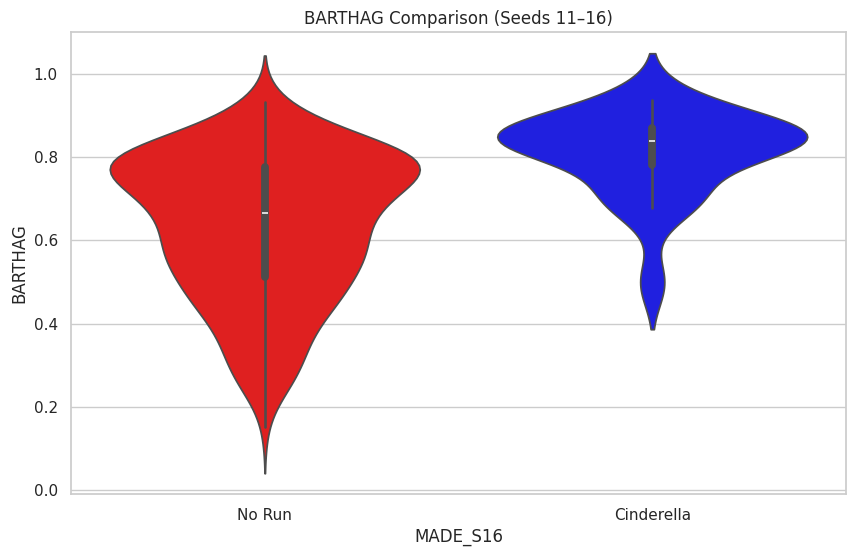

In [33]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=low_11_16,
    x="MADE_S16",
    y="BARTHAG",
    hue="MADE_S16",
    palette={False: "red", True: "blue"},
    legend=False
)

plt.xticks([0,1], ["No Run", "Cinderella"])
plt.title("BARTHAG Comparison (Seeds 11–16)")
plt.show()

Based on this violin plot, it looks like the Cinderella teams are clustered around a higher BARTHAG (A team's probability of beating an average d1 team measured between 0 and 1). To demonstrate this, below I make a probability density histogram to try and find the best display of this difference.

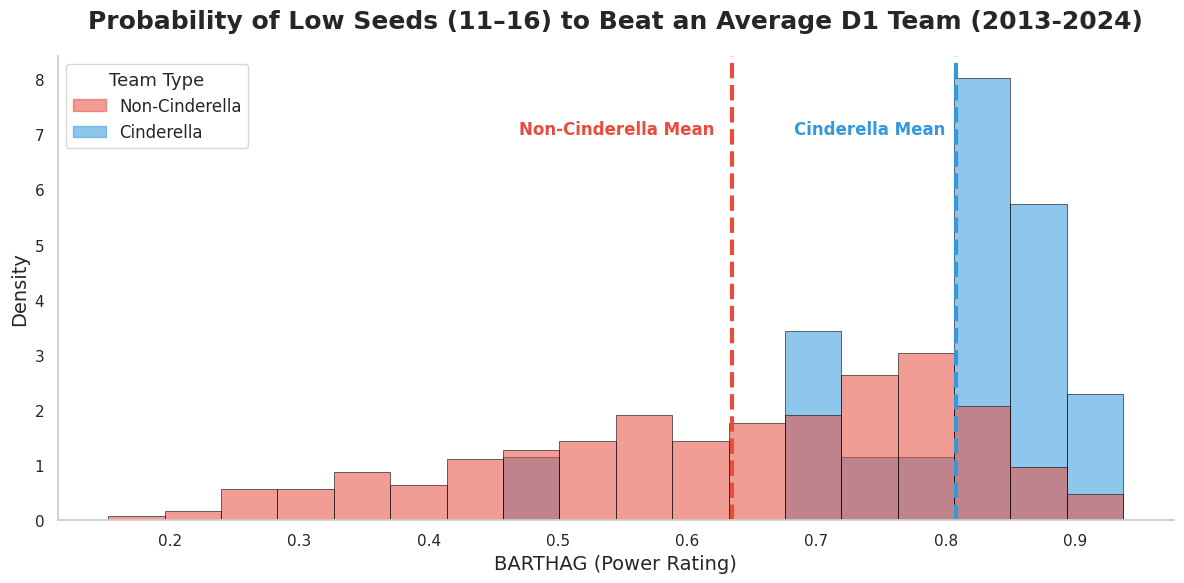

In [25]:
plt.figure(figsize=(12,6))

colors = {False: "#e74c3c", True: "#3498db"}  # non-cinderella (red), cinderella (blue)

sns.histplot(
    data=low_11_16,
    x="BARTHAG",
    hue="MADE_S16",
    bins=18,
    stat="density",
    common_norm=False,
    alpha=0.55,
    palette=colors,
    edgecolor="black",
    linewidth=0.4
)

# making lines for the mean BARTHAG difference
cinderella_mean = low_11_16[low_11_16["MADE_S16"]==True]["BARTHAG"].mean()
non_cinderella_mean = low_11_16[low_11_16["MADE_S16"]==False]["BARTHAG"].mean()

plt.axvline(cinderella_mean, color="#3498db", linestyle="--", linewidth=3)
plt.axvline(non_cinderella_mean, color="#e74c3c", linestyle="--", linewidth=3)

# plotting mean labels
plt.text(cinderella_mean - 0.125, 7, "Cinderella Mean",
         color="#3498db", fontsize=12, weight="bold")

plt.text(non_cinderella_mean -0.165, 7, "Non-Cinderella Mean",
         color="#e74c3c", fontsize=12, weight="bold")

plt.title("Probability of Low Seeds (11–16) to Beat an Average D1 Team (2013-2024)",
          fontsize=18, weight="bold", pad=20)

plt.xlabel("BARTHAG (Power Rating)", fontsize=14)
plt.ylabel("Density", fontsize=14)

# setting the legend -- I want the colors of hist bars in the legend, not the axvlines
legend_labels = ["Non-Cinderella", "Cinderella"]
handles = [plt.Rectangle((0,0),1,1, color=colors[val], alpha=0.55)
           for val in [False, True]]

plt.legend(handles, legend_labels, title="Team Type", fontsize=12, title_fontsize=13)

# cleaning
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.grid(False)
plt.show()


I found this type of plot useful in determining which values had the highest probability in a certain statistic for the Cinderella teams and Non-Cinderella teams. The mean chance of Cinderella teams to beat the average D1 team is historically about 15% higher than non-Cinderella teams. So, I explore WAB the same way. WAB is a statistic that measures "Wins above the bubble": how many more or fewer games a team won compared to what an average bubble team (team on the brink of making the tournament) would be expected to do against the same schedule.

Learn more here: https://www.ncaa.com/news/basketball-men/article/2024-11-01/ncaa-division-i-mens-basketball-committee-discusses-team-evaluation-process

#### WAB Probability Density Histogram

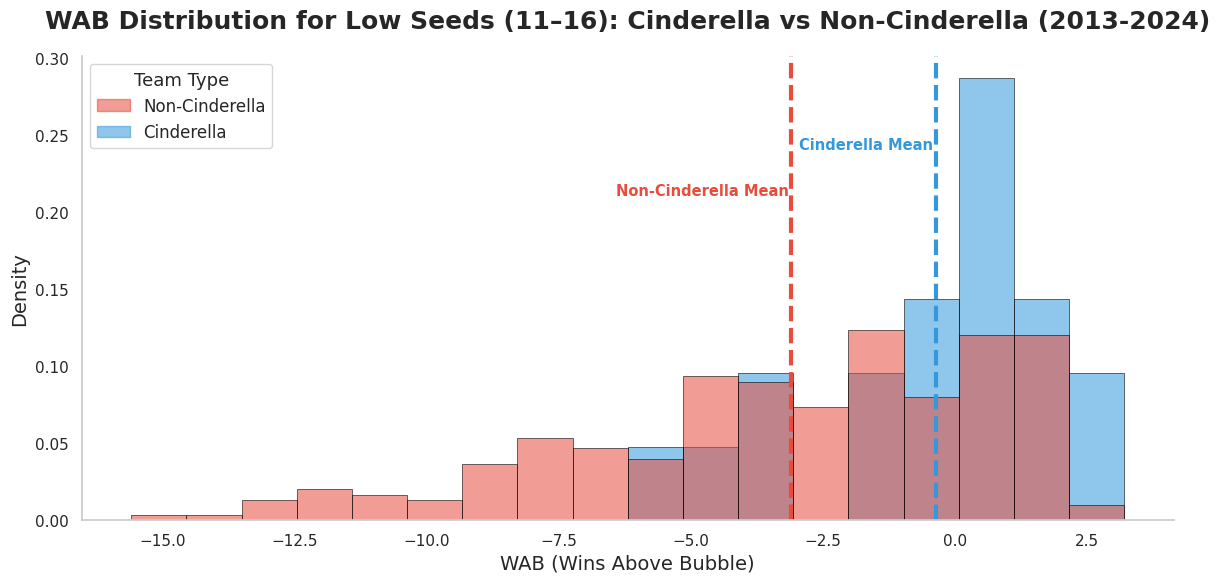

In [26]:
plt.figure(figsize=(12,6))

colors = {False: "#e74c3c", True: "#3498db"}  # non-cinderella (red), cinderella (blue)

sns.histplot(
    data=low_11_16,
    x="WAB",
    hue="MADE_S16",
    bins=18,
    stat="density",
    common_norm=False,
    alpha=0.55,
    palette=colors,
    edgecolor="black",
    linewidth=0.4
)

cinderella_mean = low_11_16[low_11_16["MADE_S16"]==True]["WAB"].mean()
non_cinderella_mean = low_11_16[low_11_16["MADE_S16"]==False]["WAB"].mean()

plt.axvline(cinderella_mean, color="#3498db", linestyle="--", linewidth=3)
plt.axvline(non_cinderella_mean, color="#e74c3c", linestyle="--", linewidth=3)

plt.text(cinderella_mean -2.6, plt.ylim()[1]*0.80,
         "Cinderella Mean", color="#3498db",
         fontsize=10.5, weight="bold")

plt.text(non_cinderella_mean -3.3, plt.ylim()[1]*0.70,
         "Non-Cinderella Mean", color="#e74c3c",
         fontsize=10.5, weight="bold")

plt.title("WAB Distribution for Low Seeds (11–16): Cinderella vs Non-Cinderella (2013-2024)",
          fontsize=18, weight="bold", pad=20)

plt.xlabel("WAB (Wins Above Bubble)", fontsize=14)
plt.ylabel("Density", fontsize=14)


legend_labels = ["Non-Cinderella", "Cinderella"]
handles = [plt.Rectangle((0,0),1,1, color=colors[val], alpha=0.55)
           for val in [False, True]]

plt.legend(handles, legend_labels, title="Team Type",
           fontsize=12, title_fontsize=13)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.grid(False)
plt.show()


This distribution of WAB also shows a somewhat significant difference between teams that have advanced 2 rounds in the tournament and those that haven't.

#### Multiple stat heatmap z-score comparison

Now I want to view multiple stats at once, looking at how Cinderella teams differ from other low-seeded teams across several metrics rather than just one. To make these stats comparable, I normalize each variable using Z-scores, which puts everything on the same scale and shows how far above or below average each group is.

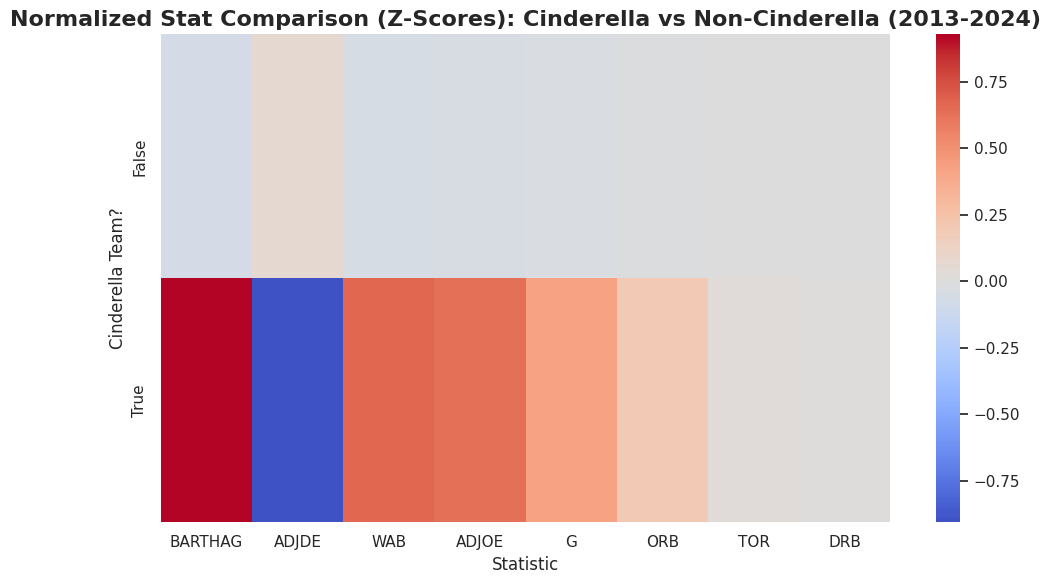

In [34]:
stats_to_compare = ["BARTHAG", "ADJDE", "WAB", "ADJOE", "G", "ORB", "TOR", "DRB"]

# normalizing based on z score (normalized stat - mean / std)
normalized = low_11_16.copy()
for col in stats_to_compare:
    normalized[col] = (normalized[col] - normalized[col].mean()) / normalized[col].std()

# taking means by group after normalizing
summary_norm = normalized.groupby("MADE_S16")[stats_to_compare].mean()


plt.figure(figsize=(10,6))
sns.heatmap(summary_norm, cmap="coolwarm", center=0, fmt=".2f")

plt.title("Normalized Stat Comparison (Z-Scores): Cinderella vs Non-Cinderella (2013-2024)",
          fontsize=16, weight="bold")
plt.ylabel("Cinderella Team?")
plt.xlabel("Statistic")

plt.tight_layout()
plt.show()


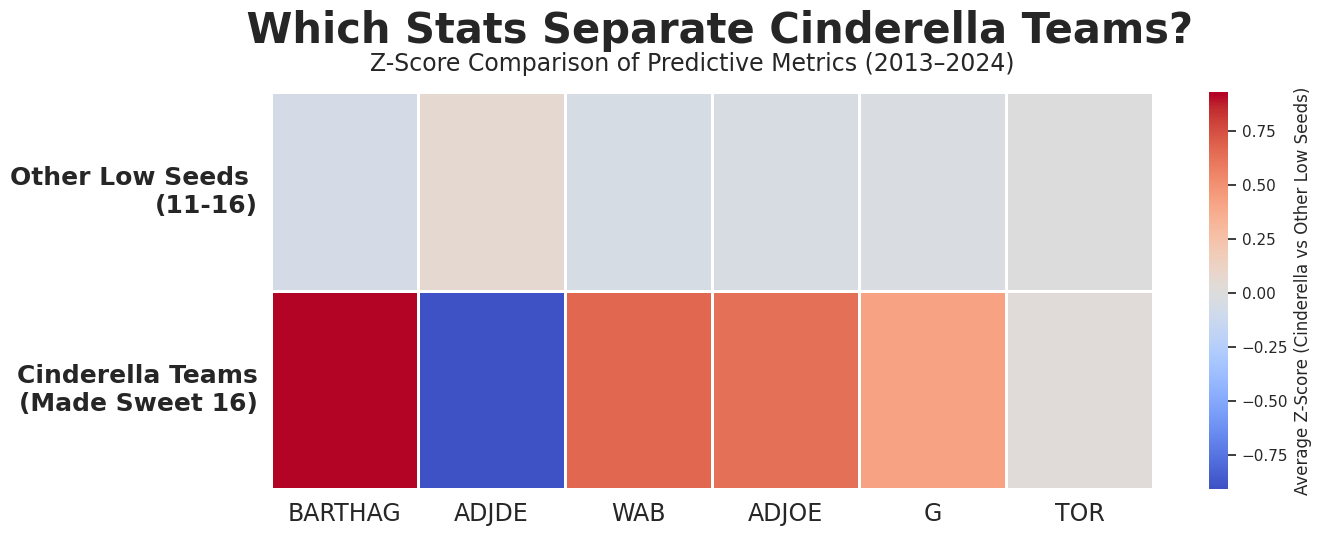

In [35]:
from scipy.stats import zscore

stats_to_plot = ["BARTHAG", "ADJDE","WAB", "ADJOE", "G", 'TOR']

# Z-scores
df_z = low_11_16.copy()
df_z[stats_to_plot] = df_z[stats_to_plot].apply(zscore)
heatmap_df = df_z.groupby("MADE_S16")[stats_to_plot].mean()


heatmap_df.index = ["Other Low Seeds", "Cinderella Teams"]
plt.figure(figsize=(14,6))

ax = sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    center=0,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Average Z-Score (Cinderella vs Other Low Seeds)"}
)

# Y-axis labels
ax.set_yticklabels(
    ["Other Low Seeds \n(11-16)", "Cinderella Teams\n(Made Sweet 16)"],
    rotation=0,
    fontsize=18,
    fontweight="bold"
)

# X-axis labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha="center",
    fontsize=17
)

ax.set_ylabel("")

plt.title(
    " Which Stats Separate Cinderella Teams?",
    fontsize=30,
    weight="bold",
    pad=10,
    y = 1.09
)

plt.suptitle(
    "Z-Score Comparison of Predictive Metrics (2013–2024)",
    fontsize=17,
    y=.82)

plt.tight_layout()
plt.savefig("heatmap_zscores.svg", bbox_inches="tight")
plt.show()


Z-scores show how far above or below average each group performs. The average is the mean of each given statistic for all teams seeded 11-16. From this heatmap, Cinderella teams are well above average in BARTHAG, WAB, offensive efficiency, and offensive rebounding (ORB). They are also better defensively (lower ADJDE). This shows clear statistical differences from regular low-seeded teams for these stats. However, in other stats like turnover rate and defensive rebound rate (TOR and DRB), there is not much of a difference. This is how I will determine what factors best differentiate Cinderella teams.

## Numeric difference test

Now I will view the statistical differences numerically. I will use cohen's d effect size as a showing of the top 5 most effective differences.

**Cohen's d effect size**: https://statisticsbyjim.com/basics/cohens-d/

In [36]:
import numpy as np

# Add inverse ADJDE so that it can be scaled correctly (since better ADJDE is a lower value)
low_11_16["ADJDE_INV"] = -low_11_16["ADJDE"]
cinderella = low_11_16[low_11_16["MADE_S16"] == True]
other_low  = low_11_16[low_11_16["MADE_S16"] == False]
numeric_stats = low_11_16.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_stats = [col for col in numeric_stats if col not in ["CINDERELLA_GRADE"]]

# effect sizes
results = []

for stat in numeric_stats:
    c = cinderella[stat].dropna()
    o = other_low[stat].dropna()

    d = (c.mean() - o.mean()) / np.sqrt((c.var() + o.var()) / 2)

    results.append([stat, c.mean(), o.mean(), c.mean() - o.mean(), d])

effect_df = pd.DataFrame(results, columns=["Stat","Mean_Cinderella","Mean_OtherLow","Difference","EffectSize"])
effect_df.sort_values("EffectSize", ascending=False).head(10)


,Stat,Mean_Cinderella,Mean_OtherLow,Difference,EffectSize
4,BARTHAG,0.80784,0.634873,0.172967,1.220978
21,ADJDE_INV,-96.17500,-100.847387,4.672387,1.024296
18,WAB,-0.36000,-3.115436,2.755436,0.851118
2,ADJOE,109.97000,106.499652,3.470348,0.681586
0,G,33.50000,31.930314,1.569686,0.392068
9,ORB,30.91000,30.031359,0.878641,0.215782
7,TOR,17.85000,17.782230,0.067770,0.034049
1,W,22.60000,22.470383,0.129617,0.032315
14,2P_D,48.10000,48.039373,0.060627,0.022175
20,YEAR,2018.35000,2018.310105,0.039895,0.010940


The top 6 statistics by Cohen's d variable in order are: BARTHAG, inverse ADJDE, WAB, ADJOE, G, ORB.

# The Cinderella Score - Giving low seed teams a grade.

After finding these five most important distinguishing stats in order, I want to come up with a sort of "grade" to evaluate which teams seeded 11-16 are most likely to advance to the sweet 16 round in March Madness. I will make a column in low_11_16 called "CINDERELLA_GRADE" which contains a number based on weighted statistics. The higher this number, the more likely a team is to be a Cinderella team.

In [37]:
low_seeds = df_playoff[df_playoff["SEED"] >= 11].copy()
deep_stages = ['S16', 'E8', 'F4', '2ND', 'Champions']
low_seeds["IS_CINDERELLA"] = low_seeds["POSTSEASON"].isin(deep_stages)
from scipy.stats import zscore

# the 6 top stats
stats_for_grade = ["BARTHAG", "ADJDE_INV", "WAB", "ADJOE", "G", "W"]

# normalize stats
for stat in stats_for_grade:
    low_seeds[f"{stat}_Z"] = zscore(low_seeds[stat])

# Since BARTHAG is the most influential individual statistic, it will have the highest weight and then move downwards.

low_11_16["ADJDE_INV"] = -low_11_16["ADJDE"]

low_11_16["CINDERELLA_GRADE"] = (
    0.35 * low_11_16["BARTHAG"] +
    0.25 * low_11_16["WAB"] +
    0.15 * low_11_16["ADJOE"] +
    0.15 * low_11_16["ADJDE_INV"] +
    0.05 * low_11_16["G"] +
    0.05 * low_11_16["ORB"]
)


These grades are mostly in the 14-24 range. To make the differences more intuitive, I set the minimum and maximum values of the grades as 0 and 100 respectively, making the scores translate to grades out of 100.  

In [ ]:
low_11_16["CINDERELLA_GRADE"] = (
    (low_11_16["CINDERELLA_GRADE"] - low_11_16["CINDERELLA_GRADE"].min()) /
    (low_11_16["CINDERELLA_GRADE"].max() - low_11_16["CINDERELLA_GRADE"].min())
) * 100

In [39]:
low_11_16.groupby("TEAM_TYPE")["CINDERELLA_GRADE"].describe()

,count,mean,std,min,25%,50%,75%,max
TEAM_TYPE,,,,,,,,
Cinderella,20.0,75.847309,16.330591,33.323599,70.859645,79.799631,82.794563,100.000000
Low Seed (No Run),287.0,55.089764,20.868182,0.000000,40.662732,56.598914,72.472397,98.201734


Based on this table, The mean and median Cinderella grade are significantly higher than the mean and median for non-Cinderella teams. **This score is a great predictor of whether a team will be a Cinderella team or not. It won't always be correct, but it gives a great insight.**

In [40]:
# Find Cinderella outliers (teams that were graded very low but still were Cinderellas)
cinderellas2 = low_11_16[low_11_16["MADE_S16"] == True]
Q1 = cinderellas2["CINDERELLA_GRADE"].quantile(0.25)
Q3 = cinderellas2["CINDERELLA_GRADE"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

cinderella_outliers = cinderellas2[
    (cinderellas2["CINDERELLA_GRADE"] < lower_bound) |
    (cinderellas2["CINDERELLA_GRADE"] > upper_bound)
]

cinderella_outliers # Use this variable to plot outliers on the distribution

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR,MADE_S16,TEAM_TYPE,ADJDE_INV,CINDERELLA_GRADE
2514,Oral Roberts,Sum,23,16,107.0,107.1,0.4981,53.6,50.4,15.7,...,35.6,71.4,-5.1,S16,15.0,2021,True,Cinderella,-107.1,33.323599
2860,Saint Peter's,MAAC,33,22,99.4,93.1,0.6786,47.5,44.2,20.1,...,29.2,65.6,-5.6,E8,15.0,2022,True,Cinderella,-93.1,51.006529


### Cinderella Score Distribution - Side by Side Boxplot

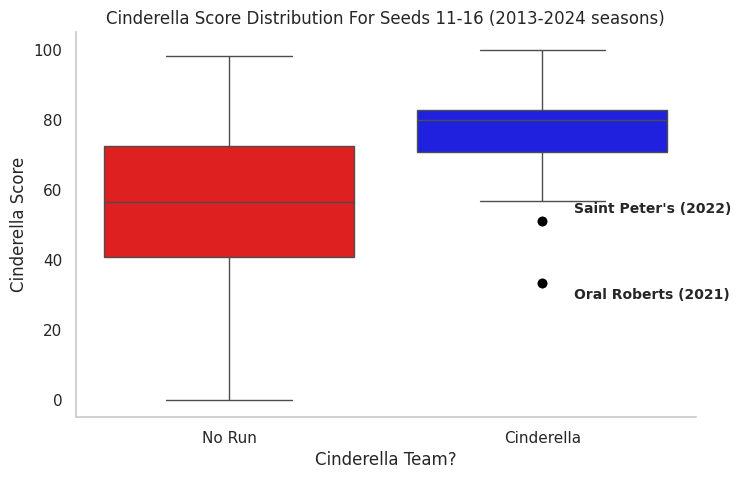

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=low_11_16,
    x="MADE_S16",
    y="CINDERELLA_GRADE",
    hue="MADE_S16",
    palette={True: "blue", False: "red"},
    legend=False
)

# Outlier scores
oral_score = low_11_16.loc[low_11_16["TEAM"] == "Oral Roberts", "CINDERELLA_GRADE"].iloc[0]
saint_score = low_11_16.loc[low_11_16["TEAM"] == "Saint Peter's", "CINDERELLA_GRADE"].iloc[0]

x_pos = 1

# Outlier annotations
plt.scatter(x_pos, oral_score, color="black", zorder=5)
plt.text(
    x_pos + 0.1, # Increased horizontal offset for better readability
    oral_score - 1.5, # Oral Roberts (lower score) moved down
    "Oral Roberts (2021)",
    fontsize=10,
    fontweight='bold',
    va="top"
)

plt.scatter(x_pos, saint_score, color="black", zorder=5)
plt.text(
    x_pos + 0.1, 
    saint_score + 1.5, # Saint Peter's (higher score) moved up
    "Saint Peter's (2022)",
    fontsize=10,
    fontweight='bold',
    va="bottom"
)

plt.xticks([0, 1], ["No Run", "Cinderella"])
plt.title("Cinderella Score Distribution For Seeds 11-16 (2013-2024 seasons)")
plt.xlabel("Cinderella Team?")
plt.ylabel("Cinderella Score")

sns.despine()
plt.grid(False)
plt.show()

From this boxplot, we can visually see the efficacy of this grade. The 50% value for the blue Cinderella teams is much higher than the red. The spread is also much more concentrated around higher values, making this score fairly reliable. Scores in the 77-85 range are typically Cinderellas, whereas scores in the 45-70 are more likely non-Cinderella low seeded teams

### Cinderella Score Distribution Violin Plot

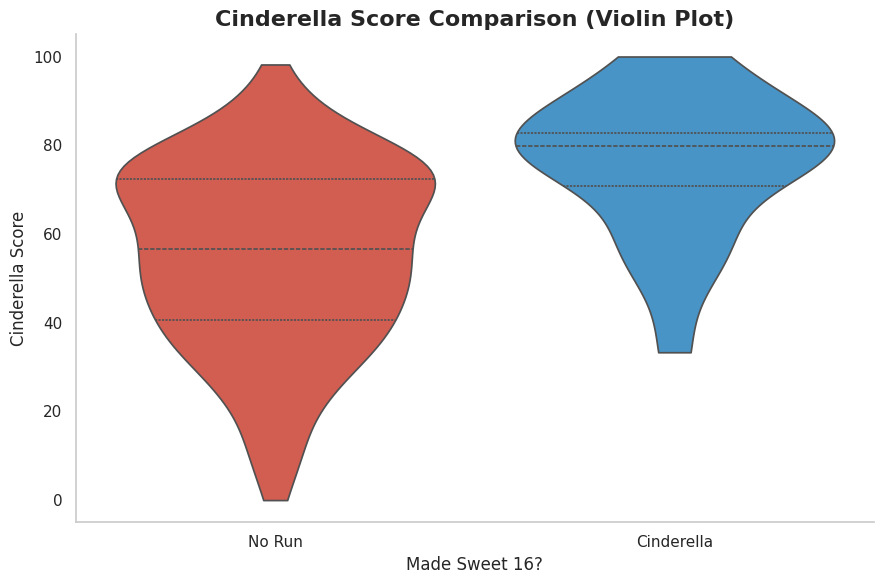

In [44]:
# Violin Plot

plt.figure(figsize=(9,6))

sns.violinplot(
    data=low_11_16,
    x="MADE_S16",
    y="CINDERELLA_GRADE",
    hue="MADE_S16",
    palette={True: "#3498db", False: "#e74c3c"},
    inner="quartile",
    cut=0,
    legend=False
)

plt.xticks([0, 1], ["No Run", "Cinderella"])
plt.title("Cinderella Score Comparison (Violin Plot)", fontsize=16, weight="bold")
plt.xlabel("Made Sweet 16?")
plt.ylabel("Cinderella Score")

sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()

This is a great visualization, but to make it even more intuitive, I make a split violin plot.

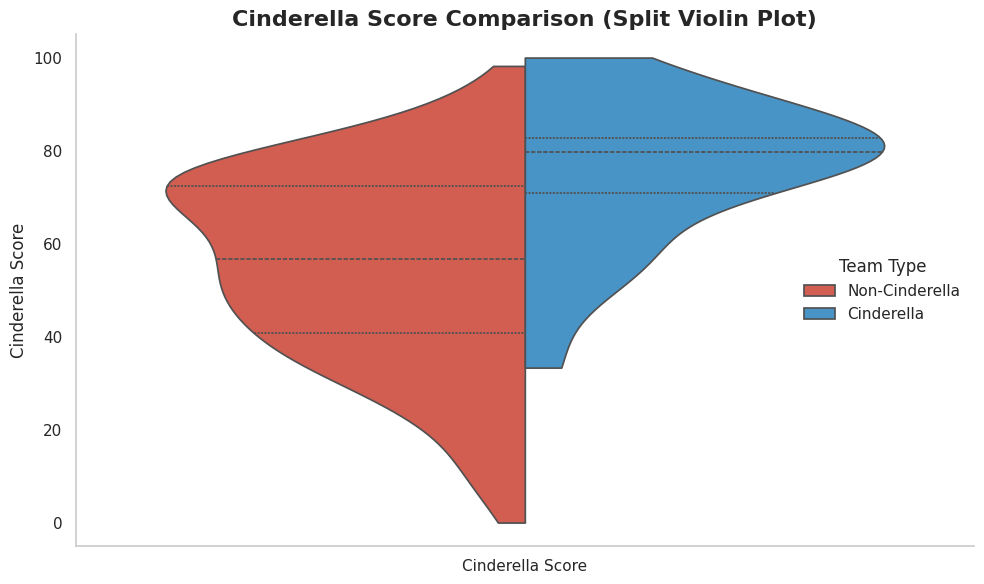

In [45]:
df = low_11_16.copy()

# Both groups need to align on the same x position for splitting
df["DUMMY"] = "Cinderella Score"

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="DUMMY",
    y="CINDERELLA_GRADE",
    hue="MADE_S16",
    split=True,
    palette={True: "#3498db", False: "#e74c3c"},
    inner="quartile",
    cut=0
)

plt.xlabel("")
plt.ylabel("Cinderella Score")
plt.title("Cinderella Score Comparison (Split Violin Plot)", fontsize=16, weight="bold")

sns.despine()
plt.grid(False)

# Legend
handles, labels = plt.gca().get_legend_handles_labels()

new_handles = [handles[0], handles[1]]
new_labels = ["Non-Cinderella", "Cinderella"]

plt.legend(
    new_handles,
    new_labels,
    title="Team Type",
    loc="center right",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

Improved version:

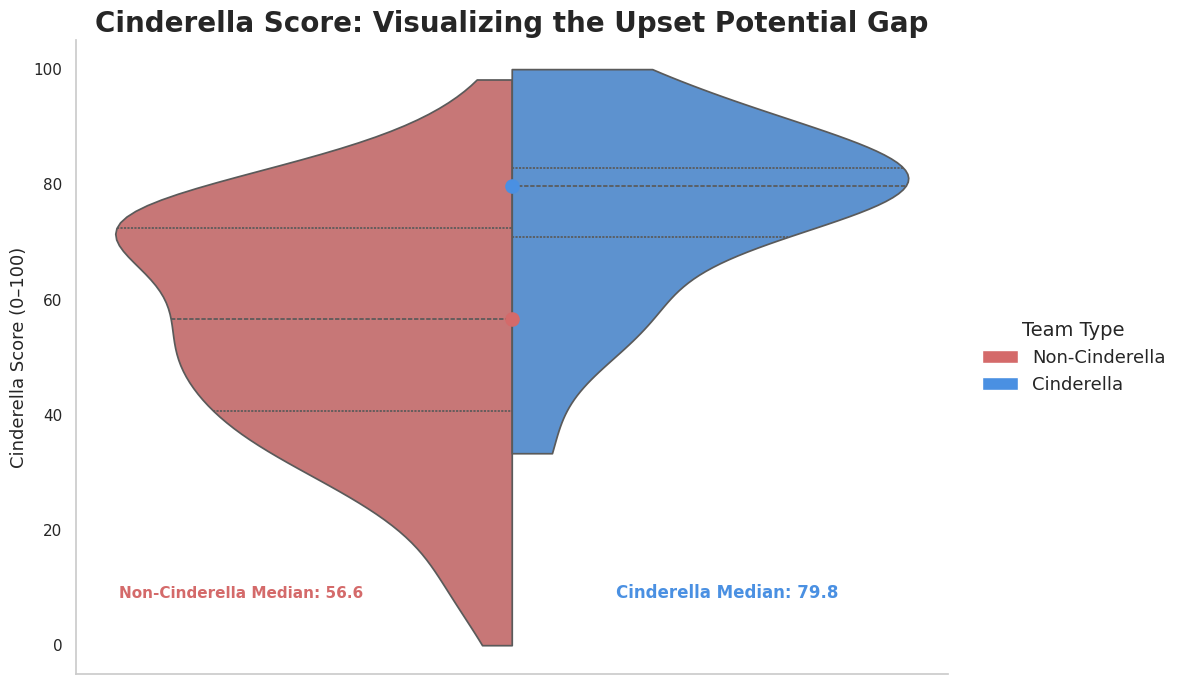

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

plt.figure(figsize=(12,7))

plt.title("Cinderella Score: Visualizing the Upset Potential Gap", fontsize=20, weight="bold")

sns.violinplot(
    data=df,
    x="DUMMY",
    y="CINDERELLA_GRADE",
    hue="MADE_S16",
    split=True,
    palette={True: "#4A90E2", False: "#D46A6A"},
    inner="quartile",
    cut=0
)

# find the medians
cinder_med = df[df["MADE_S16"]==True]["CINDERELLA_GRADE"].median()
non_med    = df[df["MADE_S16"]==False]["CINDERELLA_GRADE"].median()

x_loc = 0  # Both violins share same x position for splitting

# overlay dots on the median values
plt.scatter(x_loc, cinder_med, color="#4A90E2", s=90, zorder=5)
plt.scatter(x_loc, non_med, color="#D46A6A", s=90, zorder=5)

# Cinderella label
plt.text(
    0.62, 0.12,
    f"Cinderella Median: {cinder_med:.1f}",
    transform=plt.gca().transAxes,
    color="#4A90E2",
    fontsize=12,
    weight="bold"
)

# Non-Cinderella label
plt.text(
    0.05, 0.12,
    f"Non-Cinderella Median: {non_med:.1f}",
    transform=plt.gca().transAxes,
    color="#D46A6A",
    fontsize=11,
    weight="bold"
)

legend_items = [
    Patch(facecolor="#D46A6A", label="Non-Cinderella"),
    Patch(facecolor="#4A90E2", label="Cinderella"),
]

plt.legend(
    handles=legend_items,
    title="Team Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=13,
    title_fontsize=14
)

plt.xlabel("")
plt.ylabel("Cinderella Score (0–100)", fontsize=13)
plt.gca().set_xticklabels([])

sns.despine()
plt.grid(False)
plt.tight_layout()
plt.savefig("vplot.svg", bbox_inches="tight")
plt.show()
